# Регрессия для IC50

## 1. Загрузка и подготовка данных

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import os

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42

In [86]:
# Загрузка обработанного датасета
df = pd.read_csv('data_processed.csv')
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,...,2,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,...,0,0,0,0,0,0,0,0,0,0


In [87]:
# Определяем целевую переменную и признаки
target_col = 'IC50, mM'
feature_cols = [col for col in df.columns if col not in ['IC50, mM', 'CC50, mM', 'SI']]

X = df[feature_cols]
y = df[target_col]

print(f"Количество признаков: {len(feature_cols)}")
print(f"Целевая переменная: {target_col}")
print(f"\nСтатистика целевой переменной:")
print(y.describe())

Количество признаков: 165
Целевая переменная: IC50, mM

Статистика целевой переменной:
count     998.000000
mean      221.118757
std       400.510657
min         0.003517
25%        12.491340
50%        45.992006
75%       224.408630
max      4128.529377
Name: IC50, mM, dtype: float64


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Масштабирование для линейных моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Сохраняем scaler
with open('models/scaler_ic50.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler сохранен: models/scaler_ic50.pkl")

Train: (798, 165), Test: (200, 165)
Scaler сохранен: models/scaler_ic50.pkl


## 2. Обучение моделей

### 2.1. Linear Regression (бейзлайн)

In [89]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

results = []

def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

results.append(calculate_metrics(y_train, y_train_pred_lr, 'Linear Regression (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lr, 'Linear Regression (test)'))

print("Linear Regression результаты:")
print(f"Train R2: {results[0]['R2']:.4f}, RMSE: {results[0]['RMSE']:.4f}")
print(f"Test R2:  {results[1]['R2']:.4f}, RMSE: {results[1]['RMSE']:.4f}")

Linear Regression результаты:
Train R2: 0.4975, RMSE: 255.9692
Test R2:  -24744.5997, RMSE: 82676.1558


### 2.2. Random Forest с GridSearchCV

In [90]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший RMSE (CV): {-rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_rf, 'Random Forest (train)'))
results.append(calculate_metrics(y_test, y_test_pred_rf, 'Random Forest (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Лучший RMSE (CV): 294.6173
Train R2: 0.7716, RMSE: 172.5723
Test R2:  0.4439, RMSE: 391.9153


### 2.3. Gradient Boosting (sklearn) с GridSearchCV

In [91]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший RMSE (CV): {-gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_

y_train_pred_gb = gb_best.predict(X_train)
y_test_pred_gb = gb_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_gb, 'Gradient Boosting (train)'))
results.append(calculate_metrics(y_test, y_test_pred_gb, 'Gradient Boosting (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Лучший RMSE (CV): 294.7109
Train R2: 0.7019, RMSE: 197.1328
Test R2:  0.4388, RMSE: 393.7274


### 2.4. XGBoost с Optuna

In [92]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': RANDOM_STATE
    }
    
    model = XGBRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"Лучшие параметры: {xgb_study.best_params}")
print(f"Лучший RMSE (CV): {xgb_study.best_value:.4f}")

xgb_best = XGBRegressor(**xgb_study.best_params, random_state=RANDOM_STATE)
xgb_best.fit(X_train, y_train)

y_train_pred_xgb = xgb_best.predict(X_train)
y_test_pred_xgb = xgb_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_xgb, 'XGBoost (train)'))
results.append(calculate_metrics(y_test, y_test_pred_xgb, 'XGBoost (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

Best trial: 41. Best value: 285.417: 100%|██████████| 50/50 [01:42<00:00,  2.06s/it]


Лучшие параметры: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01356807125280402, 'subsample': 0.602761874894718, 'colsample_bytree': 0.9139929445915116, 'min_child_weight': 2}
Лучший RMSE (CV): 285.4171
Train R2: 0.7519, RMSE: 179.8401
Test R2:  0.4392, RMSE: 393.5947


### 2.5. LightGBM с Optuna

In [93]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'verbose': -1,
        'random_state': RANDOM_STATE
    }
    
    model = LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score

lgbm_study = optuna.create_study(direction='minimize')
lgbm_study.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

print(f"Лучшие параметры: {lgbm_study.best_params}")
print(f"Лучший RMSE (CV): {lgbm_study.best_value:.4f}")

lgbm_best = LGBMRegressor(**lgbm_study.best_params, verbose=-1, random_state=RANDOM_STATE)
lgbm_best.fit(X_train, y_train)

y_train_pred_lgbm = lgbm_best.predict(X_train)
y_test_pred_lgbm = lgbm_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_lgbm, 'LightGBM (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lgbm, 'LightGBM (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

Best trial: 35. Best value: 284.794: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


Лучшие параметры: {'n_estimators': 498, 'max_depth': 5, 'learning_rate': 0.012780431421048014, 'subsample': 0.9090518044911687, 'colsample_bytree': 0.7251062082519322, 'num_leaves': 46, 'min_child_samples': 39}
Лучший RMSE (CV): 284.7938
Train R2: 0.6706, RMSE: 207.2217
Test R2:  0.4206, RMSE: 400.0585


## 3. Сравнение моделей

In [94]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

test_results = results_df[results_df['Model'].str.contains('test')].copy()
test_results['Model'] = test_results['Model'].str.replace(' (test)', '')
test_results = test_results.sort_values('RMSE')

print("Рейтинг моделей по RMSE на тестовой выборке:")
for i, row in test_results.iterrows():
    print(f"{row['Model']:<25} R2={row['R2']:.4f}, RMSE={row['RMSE']:.4f}")

                    Model         MAE          MSE         RMSE            R2
Linear Regression (train)  173.946843 6.552024e+04   255.969208      0.497456
 Linear Regression (test) 6074.269645 6.835347e+09 82676.155771 -24744.599710
    Random Forest (train)  107.236521 2.978120e+04   172.572310      0.771577
     Random Forest (test)  213.801386 1.535976e+05   391.915284      0.443940
Gradient Boosting (train)  130.405260 3.886136e+04   197.132846      0.701931
 Gradient Boosting (test)  219.635868 1.550213e+05   393.727432      0.438786
          XGBoost (train)  112.676239 3.234248e+04   179.840138      0.751932
           XGBoost (test)  214.293222 1.549168e+05   393.594696      0.439164
         LightGBM (train)  127.436847 4.294082e+04   207.221665      0.670642
          LightGBM (test)  206.591370 1.600468e+05   400.058481      0.420592
Рейтинг моделей по RMSE на тестовой выборке:
Random Forest             R2=0.4439, RMSE=391.9153
XGBoost                   R2=0.4392, RMSE=393.

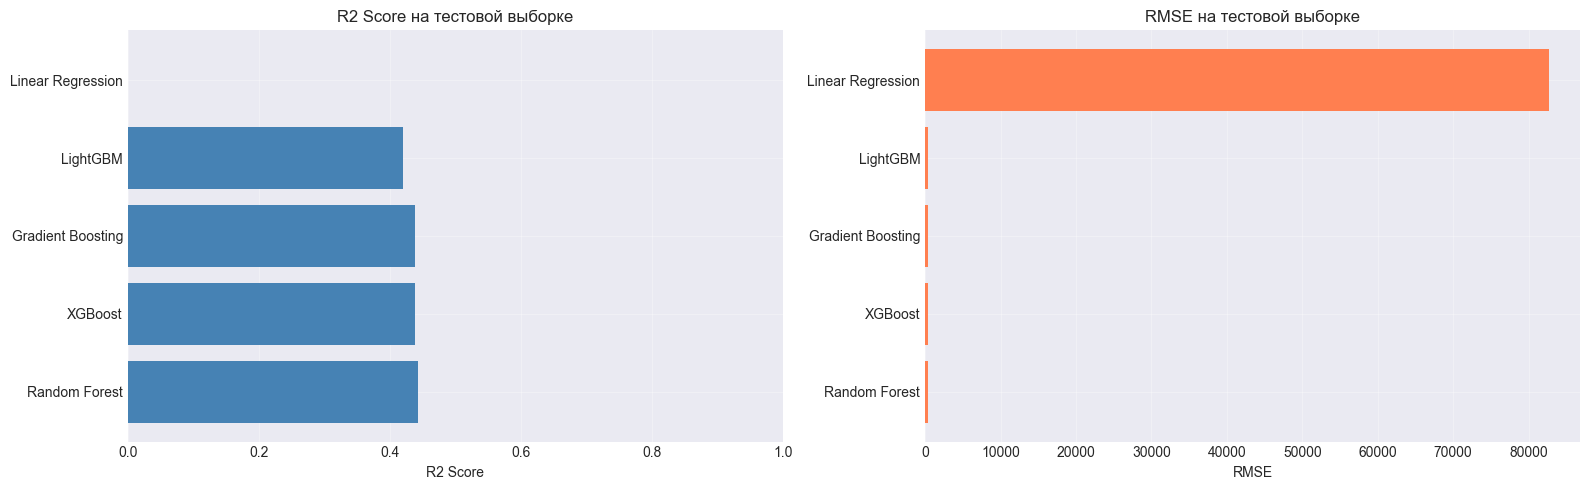

In [95]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R2 comparison
test_results_sorted = test_results.sort_values('R2', ascending=False)
axes[0].barh(test_results_sorted['Model'], test_results_sorted['R2'], color='steelblue')
axes[0].set_xlabel('R2 Score')
axes[0].set_title('R2 Score на тестовой выборке')
axes[0].set_xlim(0, 1)
axes[0].grid(True, alpha=0.3)

# RMSE comparison
test_results_sorted = test_results.sort_values('RMSE')
axes[1].barh(test_results_sorted['Model'], test_results_sorted['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE на тестовой выборке')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Визуализация предсказаний лучшей модели

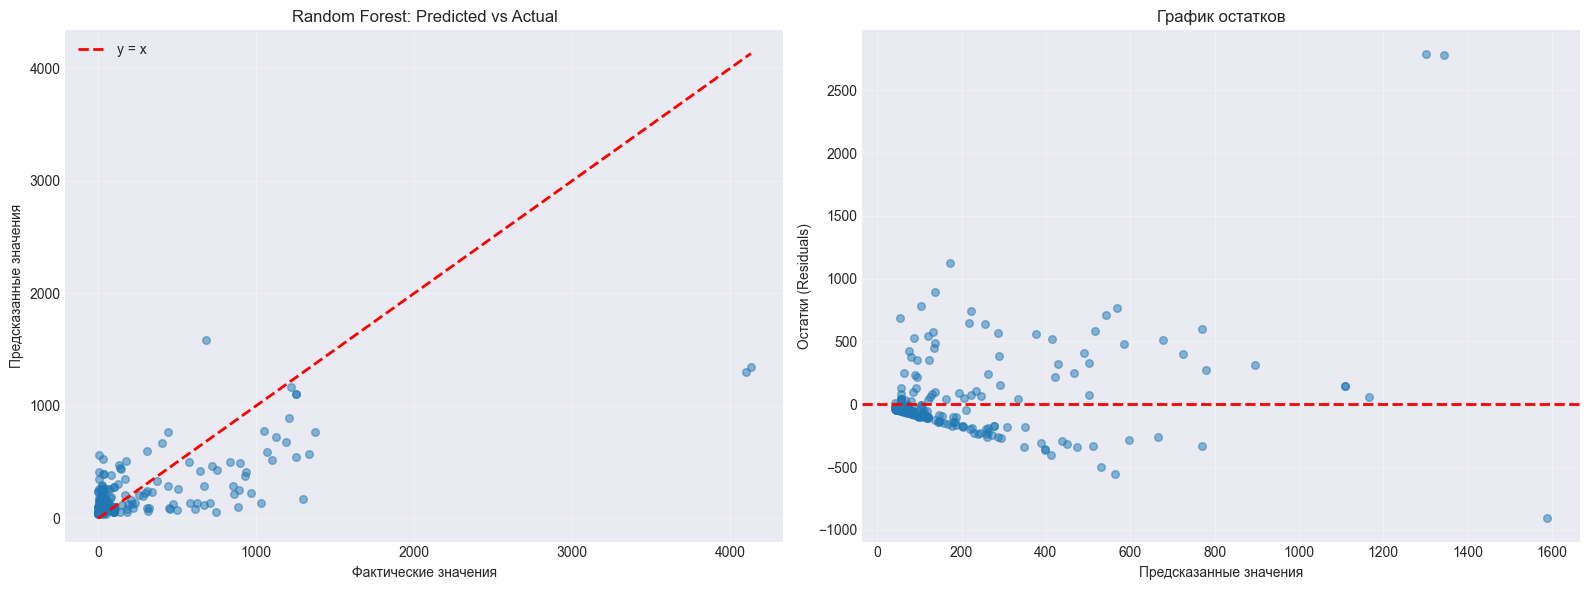

In [99]:
best_model = rf_best
y_test_pred_best = y_test_pred_rf

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
axes[0].scatter(y_test, y_test_pred_best, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='y = x')
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'Random Forest: Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred_best
axes[1].scatter(y_test_pred_best, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки (Residuals)')
axes[1].set_title('График остатков')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Важность признаков

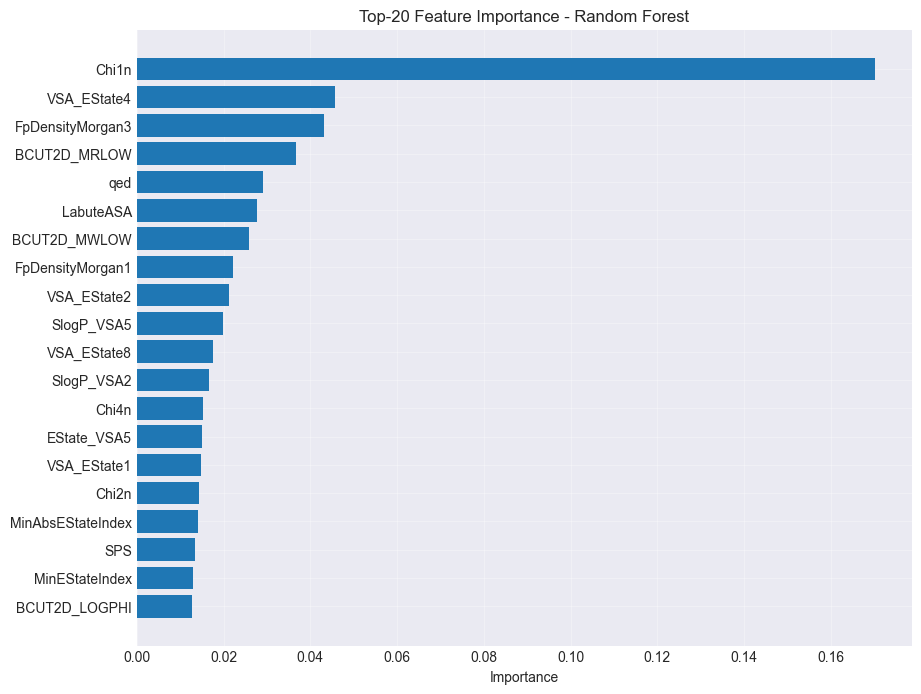


Топ-10 важных признаков:
         Feature  Importance
           Chi1n    0.170168
     VSA_EState4    0.045568
FpDensityMorgan3    0.043148
    BCUT2D_MRLOW    0.036802
             qed    0.029127
       LabuteASA    0.027628
    BCUT2D_MWLOW    0.025807
FpDensityMorgan1    0.022277
     VSA_EState2    0.021244
      SlogP_VSA5    0.019765


In [100]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title(f'Top-20 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10).to_string(index=False))

## 6. Сохранение лучшей модели

In [101]:
# Сохранение лучшей модели
model_info = {
    'model': best_model,
    'model_name': 'Random Forest',
    'features': feature_cols,
    'scaler': scaler,
    'metrics': {
        'MAE': test_results.iloc[0]['MAE'],
        'MSE': test_results.iloc[0]['MSE'],
        'RMSE': test_results.iloc[0]['RMSE'],
        'R2': test_results.iloc[0]['R2']
    }
}

with open('models/best_ic50_regression.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"Лучшая модель сохранена: models/best_ic50_regression.pkl")
print(f"Model: Random Forest")
print(f"Metrics: R2={model_info['metrics']['R2']:.4f}, RMSE={model_info['metrics']['RMSE']:.4f}")

Лучшая модель сохранена: models/best_ic50_regression.pkl
Model: Random Forest
Metrics: R2=0.4439, RMSE=391.9153


## 7. Выводы

### Результаты:
- **Лучшая модель**: Random Forest 
- **Метрики на тестовой выборке**:
  - R2: 0.4439
  - RMSE: 391.9153

### Рекомендации по улучшению:
- Генерация новых признаков на основе доменных знаний
- Использование стекинга лучших моделей
- Подбор дополнительных гиперпараметров
- Искусственная генерация новых данных